In [3]:
import pandas as pd

train = pd.read_excel("CPRI_Hackathon_Screening_Dataset_PARTICIPANT.xlsx", sheet_name="Training_Data")
test = pd.read_excel("CPRI_Hackathon_Screening_Dataset_PARTICIPANT.xlsx", sheet_name="Test_Data")

sensor_cols = ["Sensor_S1", "Sensor_S2", "Sensor_S3", "Sensor_S4"]

# Check for negative values in any sensor column, both train and test
for c in sensor_cols:
    neg_train = train[train[c] < 0]
    neg_test = test[test[c] < 0]
    if len(neg_train):
        print(f"TRAIN {c}: {len(neg_train)} negative value(s)")
        print(neg_train[["Test_ID", c, "Validity_Label"]])
    if len(neg_test):
        print(f"TEST {c}: {len(neg_test)} negative value(s)")
        print(neg_test[["Test_ID", c]])

TRAIN Sensor_S2: 1 negative value(s)
      Test_ID  Sensor_S2 Validity_Label
291  TRN-0203    -0.2015        Invalid
TEST Sensor_S2: 1 negative value(s)
     Test_ID  Sensor_S2
10  TST-0213    -1.5509


In [4]:
train.loc[train["Sensor_S2"] < 0, "Sensor_S2"] = 0
test.loc[test["Sensor_S2"] < 0, "Sensor_S2"] = 0

In [5]:
print(train.loc[train["Test_ID"] == "TRN-0203", ["Test_ID", "Sensor_S2", "Validity_Label"]])

      Test_ID  Sensor_S2 Validity_Label
291  TRN-0203        0.0        Invalid


In [6]:
for c in ["Sensor_S1", "Sensor_S2", "Sensor_S3", "Sensor_S4"]:
    flag_name = c.replace("Sensor_", "") + "_missing"
    train[flag_name] = train[c].isna().astype(int)
for c in ["Sensor_S1", "Sensor_S2", "Sensor_S3", "Sensor_S4"]:
    flag_name = c.replace("Sensor_", "") + "_missing"
    test[flag_name] = test[c].isna().astype(int)

In [7]:
print(train[["S1_missing", "S2_missing", "S3_missing", "S4_missing"]].sum())

print(test[["S1_missing", "S2_missing", "S3_missing", "S4_missing"]].sum())

S1_missing     6
S2_missing     2
S3_missing     7
S4_missing    29
dtype: int64
S1_missing     1
S2_missing     3
S3_missing     2
S4_missing    11
dtype: int64


In [8]:
for c in ["S1_missing", "S2_missing", "S3_missing", "S4_missing"]:
    print(c)
    print(train.groupby(c)["Validity_Label"].value_counts(normalize=True))
    print()

S1_missing
S1_missing  Validity_Label
0           Valid             0.871227
            Invalid           0.128773
1           Invalid           1.000000
Name: proportion, dtype: float64

S2_missing
S2_missing  Validity_Label
0           Valid             0.867735
            Invalid           0.132265
1           Invalid           1.000000
Name: proportion, dtype: float64

S3_missing
S3_missing  Validity_Label
0           Valid             0.872105
            Invalid           0.127895
1           Invalid           1.000000
Name: proportion, dtype: float64

S4_missing
S4_missing  Validity_Label
0           Valid             0.861998
            Invalid           0.138002
1           Valid             1.000000
Name: proportion, dtype: float64



In [9]:
print("Train missing rates:", train[["S1_missing","S2_missing","S3_missing","S4_missing"]].mean())
print("Test missing rates:", test[["S1_missing","S2_missing","S3_missing","S4_missing"]].mean())

Train missing rates: S1_missing    0.006
S2_missing    0.002
S3_missing    0.007
S4_missing    0.029
dtype: float64
Test missing rates: S1_missing    0.002857
S2_missing    0.008571
S3_missing    0.005714
S4_missing    0.031429
dtype: float64


In [10]:
input_cols = ["Applied_Voltage_kV", "Load_Current_A", "Ambient_Temperature_C",
              "Test_Duration_min", "Sensor_S1", "Sensor_S2", "Sensor_S3", "Sensor_S4"]

In [11]:
train["is_duplicate_input"] = train.duplicated(subset=input_cols, keep=False).astype(int)

In [12]:
print(train["is_duplicate_input"].sum())
# Expect: 24

print(train.groupby("is_duplicate_input")["Validity_Label"].value_counts(normalize=True))
# Expect: is_duplicate_input=1 → 100% Invalid

24
is_duplicate_input  Validity_Label
0                   Valid             0.887295
                    Invalid           0.112705
1                   Invalid           1.000000
Name: proportion, dtype: float64


In [15]:
combined = pd.concat([train[input_cols], test[input_cols]], keys=["train", "test"])
dup_mask = combined.duplicated(subset=input_cols, keep=False)
test["is_duplicate_input"] = dup_mask.loc["test"].astype(int).values

In [16]:
print(test["is_duplicate_input"].sum())

8


In [19]:
s1_median = train["Sensor_S1"].median()
s2_median = train["Sensor_S2"].median()
s3_median = train["Sensor_S3"].median()

print(s1_median, s2_median, s3_median)

13.627749999999999 13.57855 16.9269


In [20]:
train["Sensor_S1"] = train["Sensor_S1"].fillna(s1_median)
train["Sensor_S2"] = train["Sensor_S2"].fillna(s2_median)
train["Sensor_S3"] = train["Sensor_S3"].fillna(s3_median)

In [21]:
test["Sensor_S1"] = test["Sensor_S1"].fillna(s1_median)
test["Sensor_S2"] = test["Sensor_S2"].fillna(s2_median)
test["Sensor_S3"] = test["Sensor_S3"].fillna(s3_median)

In [22]:
print(train[["Sensor_S1", "Sensor_S2", "Sensor_S3"]].isna().sum())
print(test[["Sensor_S1", "Sensor_S2", "Sensor_S3"]].isna().sum())

Sensor_S1    0
Sensor_S2    0
Sensor_S3    0
dtype: int64
Sensor_S1    0
Sensor_S2    0
Sensor_S3    0
dtype: int64


In [23]:
print(train["S1_missing"].sum(), train["S2_missing"].sum(), train["S3_missing"].sum())

6 2 7


In [24]:
train = train.drop(columns=["Sensor_S4"])
test = test.drop(columns=["Sensor_S4"])

In [25]:
print("S4_missing" in train.columns, "S4_missing" in test.columns)

print(train["S4_missing"].sum(), test["S4_missing"].sum())

True True
29 11


In [26]:
print("Sensor_S4" in train.columns, "Sensor_S4" in test.columns)

False False


In [27]:
print(sorted(train.columns))
print(sorted(test.columns))

['Ambient_Temperature_C', 'Applied_Voltage_kV', 'Load_Current_A', 'Reference_Parameter', 'S1_missing', 'S2_missing', 'S3_missing', 'S4_missing', 'Sensor_S1', 'Sensor_S2', 'Sensor_S3', 'Test_Duration_min', 'Test_ID', 'Validity_Label', 'is_duplicate_input']
['Ambient_Temperature_C', 'Applied_Voltage_kV', 'Load_Current_A', 'S1_missing', 'S2_missing', 'S3_missing', 'S4_missing', 'Sensor_S1', 'Sensor_S2', 'Sensor_S3', 'Test_Duration_min', 'Test_ID', 'is_duplicate_input']


In [28]:
check_cols = ["Sensor_S1", "Sensor_S2", "Sensor_S3", "Reference_Parameter", "Ambient_Temperature_C"]

for c in check_cols:
    q1, q3 = train[c].quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out = train[(train[c] < lo) | (train[c] > hi)]
    print(c, "outliers:", len(out))
    if len(out):
        print(out["Validity_Label"].value_counts().to_dict())

Sensor_S1 outliers: 5
{'Invalid': 5}
Sensor_S2 outliers: 15
{'Invalid': 15}
Sensor_S3 outliers: 2
{'Invalid': 2}
Reference_Parameter outliers: 6
{'Valid': 6}
Ambient_Temperature_C outliers: 4
{'Valid': 4}


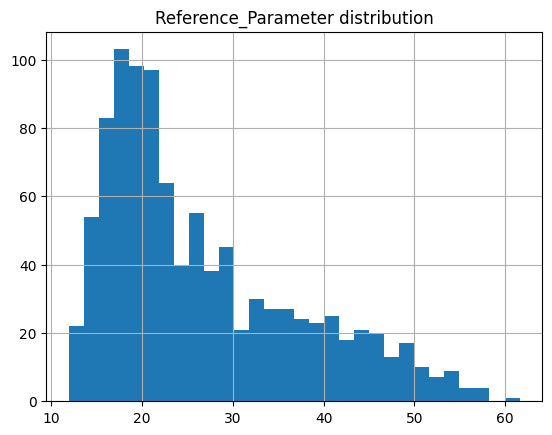

In [30]:
import matplotlib.pyplot as plt
train["Reference_Parameter"].hist(bins=30)
plt.title("Reference_Parameter distribution")
plt.show()

In [31]:
train["Validity_Label_enc"] = train["Validity_Label"].map({"Valid": 0, "Invalid": 1})

In [32]:
print(train["Validity_Label_enc"].value_counts(dropna=False))
# Expect: 0 → 866, 1 → 134, no NaN

Validity_Label_enc
0    866
1    134
Name: count, dtype: int64


In [33]:
print(train["Validity_Label"].unique())
# Expect exactly: array(['Valid', 'Invalid'], dtype=object) — no typos, no extra whitespace

['Valid' 'Invalid']


In [34]:
feature_cols = [
    "Applied_Voltage_kV", "Load_Current_A", "Ambient_Temperature_C", "Test_Duration_min",
    "Sensor_S1", "Sensor_S2", "Sensor_S3",
    "S1_missing", "S2_missing", "S3_missing", "S4_missing",
    "is_duplicate_input"
]
print(len(feature_cols))  # should be 12

12


In [35]:
missing_in_train = [c for c in feature_cols if c not in train.columns]
missing_in_test = [c for c in feature_cols if c not in test.columns]
print("Missing in train:", missing_in_train)
print("Missing in test:", missing_in_test)
# Both should print empty lists

Missing in train: []
Missing in test: []


In [36]:
for c in feature_cols:
    print(c, train[c].dtype, test[c].dtype)

Applied_Voltage_kV float64 float64
Load_Current_A float64 float64
Ambient_Temperature_C float64 float64
Test_Duration_min float64 float64
Sensor_S1 float64 float64
Sensor_S2 float64 float64
Sensor_S3 float64 float64
S1_missing int64 int64
S2_missing int64 int64
S3_missing int64 int64
S4_missing int64 int64
is_duplicate_input int64 int64


In [37]:
print(train[feature_cols].isna().sum().sum())  # should be 0
print(test[feature_cols].isna().sum().sum())   # should be 0

0
0


In [38]:
print(len(train), len(test))
# Expect: 1000, 350

1000 350


In [39]:
train.to_csv("train_cleaned.csv", index=False)
test.to_csv("test_cleaned.csv", index=False)